In [1]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs disponíveis:", gpus)

if gpus:
    print("GPU reconhecida pelo TensorFlow.")
else:
    print("ATENÇÃO: nenhuma GPU foi reconhecida.")

TensorFlow: 2.20.0
GPUs disponíveis: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU reconhecida pelo TensorFlow.


In [2]:
SEED = 42

tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

print("Seed global:", SEED)
print("Determinismo do TensorFlow ativado.")

Seed global: 42
Determinismo do TensorFlow ativado.


In [3]:
import pandas as pd
import os

CAMINHO_CSV = (
    "/kaggle/input/notebooks/monicalanjos071829/"
    "01-verificacao-dataset-pneumonia/"
    "base_modelagem_divisao_80_10_10.csv"
)

df = pd.read_csv(CAMINHO_CSV)

print("Dimensão da base:", df.shape)
print("\nDistribuição por conjunto:")
print(df["divisao_nova"].value_counts())

print("\nDistribuição por conjunto e classe:")
print(
    pd.crosstab(
        df["divisao_nova"],
        df["classe"]
    )
)

print("\nValores ausentes em divisao_nova:", df["divisao_nova"].isna().sum())
print("Valores ausentes em classe:", df["classe"].isna().sum())

Dimensão da base: (5824, 11)

Distribuição por conjunto:
divisao_nova
treino       4682
teste         581
validacao     561
Name: count, dtype: int64

Distribuição por conjunto e classe:
classe        NORMAL  PNEUMONIA
divisao_nova                   
teste            166        415
treino          1259       3423
validacao        154        407

Valores ausentes em divisao_nova: 0
Valores ausentes em classe: 0


In [4]:
print("Colunas disponíveis:")
print(df.columns.tolist())

print("\nPrimeiras 3 linhas:")
print(df.head(3))

Colunas disponíveis:
['caminho', 'nome_arquivo', 'divisao_original', 'classe', 'extensao', 'sha256', 'grupo_candidato', 'duplicata_exata', 'copia_excedente', 'fold', 'divisao_nova']

Primeiras 3 linhas:
                                             caminho       nome_arquivo  \
0  /kaggle/input/datasets/paultimothymooney/chest...  IM-0115-0001.jpeg   
1  /kaggle/input/datasets/paultimothymooney/chest...  IM-0117-0001.jpeg   
2  /kaggle/input/datasets/paultimothymooney/chest...  IM-0119-0001.jpeg   

  divisao_original  classe extensao  \
0            train  NORMAL    .jpeg   
1            train  NORMAL    .jpeg   
2            train  NORMAL    .jpeg   

                                              sha256 grupo_candidato  \
0  de2079fb45d4bb0e4c6a48481e7b6ee31ab7601e83b43c...         IM-0115   
1  05bc425eda168493cbe38eea4c079edbbfad1e17e34778...         IM-0117   
2  46c9ea6d3c6ef09eac134e3cb3294caaa63aa2b8c53278...         IM-0119   

   duplicata_exata  copia_excedente  fold divisao_

In [5]:
MAPA_CLASSES = {
    "NORMAL": 0,
    "PNEUMONIA": 1
}

df["label"] = df["classe"].map(MAPA_CLASSES)

df_treino = df[df["divisao_nova"] == "treino"].copy()
df_validacao = df[df["divisao_nova"] == "validacao"].copy()
df_teste = df[df["divisao_nova"] == "teste"].copy()

print("Treino:", df_treino.shape)
print("Validação:", df_validacao.shape)
print("Teste:", df_teste.shape)

print("\nDistribuição dos labels no treino:")
print(df_treino["label"].value_counts().sort_index())

print("\nDistribuição dos labels na validação:")
print(df_validacao["label"].value_counts().sort_index())

print("\nDistribuição dos labels no teste:")
print(df_teste["label"].value_counts().sort_index())

print("\nLabels ausentes:", df["label"].isna().sum())

Treino: (4682, 12)
Validação: (561, 12)
Teste: (581, 12)

Distribuição dos labels no treino:
label
0    1259
1    3423
Name: count, dtype: int64

Distribuição dos labels na validação:
label
0    154
1    407
Name: count, dtype: int64

Distribuição dos labels no teste:
label
0    166
1    415
Name: count, dtype: int64

Labels ausentes: 0


In [6]:
df["arquivo_existe"] = df["caminho"].apply(os.path.exists)

print("Total de imagens:", len(df))
print("Arquivos encontrados:", df["arquivo_existe"].sum())
print("Arquivos ausentes:", (~df["arquivo_existe"]).sum())

print("\nArquivos ausentes por conjunto:")
print(
    df.loc[~df["arquivo_existe"], "divisao_nova"]
      .value_counts()
)

Total de imagens: 5824
Arquivos encontrados: 5824
Arquivos ausentes: 0

Arquivos ausentes por conjunto:
Series([], Name: count, dtype: int64)


In [7]:
IMG_SIZE = (224, 224)

def carregar_e_preprocessar_resnet(caminho, label):
    imagem = tf.io.read_file(caminho)
    imagem = tf.io.decode_jpeg(imagem, channels=3)

    imagem = tf.image.resize(imagem, IMG_SIZE)
    imagem = tf.cast(imagem, tf.float32)

    imagem = tf.keras.applications.resnet50.preprocess_input(imagem)

    label = tf.cast(label, tf.float32)

    return imagem, label

In [8]:
exemplo = df_treino.iloc[0]

imagem_teste, label_teste = carregar_e_preprocessar_resnet(
    tf.constant(exemplo["caminho"]),
    tf.constant(exemplo["label"])
)

print("Arquivo:", exemplo["nome_arquivo"])
print("Classe original:", exemplo["classe"])
print("Formato da imagem:", imagem_teste.shape)
print("Tipo da imagem:", imagem_teste.dtype)
print("Label:", label_teste.numpy())
print("Valor mínimo:", float(tf.reduce_min(imagem_teste)))
print("Valor máximo:", float(tf.reduce_max(imagem_teste)))

Arquivo: IM-0117-0001.jpeg
Classe original: NORMAL
Formato da imagem: (224, 224, 3)
Tipo da imagem: <dtype: 'float32'>
Label: 0.0
Valor mínimo: -123.68000030517578
Valor máximo: 151.06100463867188


I0000 00:00:1787020766.278606      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [9]:
BATCH_SIZE = 32
SEED = 42

ds_treino = tf.data.Dataset.from_tensor_slices(
    (
        df_treino["caminho"].values,
        df_treino["label"].values
    )
)

ds_validacao = tf.data.Dataset.from_tensor_slices(
    (
        df_validacao["caminho"].values,
        df_validacao["label"].values
    )
)

ds_teste = tf.data.Dataset.from_tensor_slices(
    (
        df_teste["caminho"].values,
        df_teste["label"].values
    )
)

ds_treino = (
    ds_treino
    .shuffle(
        buffer_size=len(df_treino),
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .map(
        carregar_e_preprocessar_resnet,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

ds_validacao = (
    ds_validacao
    .map(
        carregar_e_preprocessar_resnet,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

ds_teste = (
    ds_teste
    .map(
        carregar_e_preprocessar_resnet,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Pipelines tf.data criados com sucesso.")

Pipelines tf.data criados com sucesso.


In [10]:
for imagens_batch, labels_batch in ds_treino.take(1):
    print("Formato das imagens:", imagens_batch.shape)
    print("Formato dos labels:", labels_batch.shape)

    print("Tipo das imagens:", imagens_batch.dtype)
    print("Tipo dos labels:", labels_batch.dtype)

    print("Valor mínimo do batch:", float(tf.reduce_min(imagens_batch)))
    print("Valor máximo do batch:", float(tf.reduce_max(imagens_batch)))

    print("Labels do batch:")
    print(labels_batch.numpy())

Formato das imagens: (32, 224, 224, 3)
Formato dos labels: (32,)
Tipo das imagens: <dtype: 'float32'>
Tipo dos labels: <dtype: 'float32'>
Valor mínimo do batch: -123.68000030517578
Valor máximo do batch: 151.06100463867188
Labels do batch:
[1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1.
 1. 1. 1. 1. 1. 0. 1. 0.]


In [11]:
from tensorflow.keras.applications import ResNet50

base_resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("ResNet50 carregada com sucesso.")
print("Formato da saída:", base_resnet.output_shape)
print("Número de camadas:", len(base_resnet.layers))
print("Parâmetros da base:", base_resnet.count_params())
print("Base treinável atualmente:", base_resnet.trainable)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
ResNet50 carregada com sucesso.
Formato da saída: (None, 7, 7, 2048)
Número de camadas: 175
Parâmetros da base: 23587712
Base treinável atualmente: True


In [12]:
base_resnet.trainable = False

print("Base treinável:", base_resnet.trainable)
print("Parâmetros treináveis da base:",
      sum(tf.keras.backend.count_params(p) for p in base_resnet.trainable_weights))
print("Parâmetros não treináveis da base:",
      sum(tf.keras.backend.count_params(p) for p in base_resnet.non_trainable_weights))

Base treinável: False
Parâmetros treináveis da base: 0
Parâmetros não treináveis da base: 23587712


In [13]:
from tensorflow.keras import layers, Model

inputs = tf.keras.Input(shape=(224, 224, 3), name="imagem")

x = base_resnet(inputs, training=False)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dropout(
    0.5,
    name="dropout"
)(x)

outputs = layers.Dense(
    1,
    activation="sigmoid",
    name="classificacao"
)(x)

modelo_resnet = Model(
    inputs=inputs,
    outputs=outputs,
    name="resnet50_transfer_learning"
)

modelo_resnet.summary()

Model: "resnet50_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagem (InputLayer)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classificacao (Dense)           │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [14]:
modelo_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        ),
        tf.keras.metrics.AUC(
            name="roc_auc",
            curve="ROC"
        )
    ]
)

print("Modelo compilado com sucesso.")
print("Learning rate:", float(modelo_resnet.optimizer.learning_rate.numpy()))

Modelo compilado com sucesso.
Learning rate: 0.0010000000474974513


In [15]:
CAMINHO_MODELO_RESNET = "/kaggle/working/resnet50_transfer_learning_fase1_best.keras"

early_stopping_resnet = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

checkpoint_resnet = tf.keras.callbacks.ModelCheckpoint(
    filepath=CAMINHO_MODELO_RESNET,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

callbacks_resnet = [
    early_stopping_resnet,
    checkpoint_resnet
]

print("Callbacks configurados com sucesso.")
print("Checkpoint:", CAMINHO_MODELO_RESNET)

Callbacks configurados com sucesso.
Checkpoint: /kaggle/working/resnet50_transfer_learning_fase1_best.keras


In [16]:
print("=== CHECAGEM PRÉ-TREINAMENTO ===")

print("\nDados:")
print("Treino:", len(df_treino))
print("Validação:", len(df_validacao))
print("Teste:", len(df_teste))

print("\nConfiguração:")
print("Entrada:", (224, 224, 3))
print("Batch size:", BATCH_SIZE)
print("Seed:", SEED)

print("\nResNet50:")
print("Base treinável:", base_resnet.trainable)
print("Parâmetros totais:", modelo_resnet.count_params())

parametros_treinaveis = sum(
    tf.keras.backend.count_params(p)
    for p in modelo_resnet.trainable_weights
)

print("Parâmetros treináveis:", parametros_treinaveis)

print("\nCheckpoint:")
print(CAMINHO_MODELO_RESNET)

=== CHECAGEM PRÉ-TREINAMENTO ===

Dados:
Treino: 4682
Validação: 561
Teste: 581

Configuração:
Entrada: (224, 224, 3)
Batch size: 32
Seed: 42

ResNet50:
Base treinável: False
Parâmetros totais: 23589761
Parâmetros treináveis: 2049

Checkpoint:
/kaggle/working/resnet50_transfer_learning_fase1_best.keras


In [17]:
EPOCHS = 30

historico_resnet_fase1 = modelo_resnet.fit(
    ds_treino,
    validation_data=ds_validacao,
    epochs=EPOCHS,
    callbacks=callbacks_resnet,
    verbose=1
)

Epoch 1/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.7994 - loss: 0.4442 - precision: 0.8517 - recall: 0.8728 - roc_auc: 0.8381
Epoch 1: val_loss improved from None to 0.19555, saving model to /kaggle/working/resnet50_transfer_learning_fase1_best.keras

Epoch 1: finished saving model to /kaggle/working/resnet50_transfer_learning_fase1_best.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 37s 180ms/step - accuracy: 0.8751 - loss: 0.2941 - precision: 0.9068 - recall: 0.9240 - roc_auc: 0.9309 - val_accuracy: 0.9251 - val_loss: 0.1956 - val_precision: 0.9551 - val_recall: 0.9410 - val_roc_auc: 0.9715
Epoch 2/30
146/147 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9308 - loss: 0.1880 - precision: 0.9461 - recall: 0.9585 - roc_auc: 0.9724
Epoch 2: val_loss improved from 0.19555 to 0.16254, saving model to /kaggle/working/resnet50_transfer_learning_fase1_best.keras

Epoch 2: finished saving model to /kaggle/working/resnet50_transfer_learning_fase1_best.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 

In [18]:
historico_df_resnet = pd.DataFrame(
    historico_resnet_fase1.history
)

historico_df_resnet.insert(
    0,
    "epoca",
    range(1, len(historico_df_resnet) + 1)
)

indice_melhor = historico_df_resnet["val_loss"].idxmin()

melhor_resultado = historico_df_resnet.loc[
    indice_melhor,
    [
        "epoca",
        "loss",
        "accuracy",
        "precision",
        "recall",
        "roc_auc",
        "val_loss",
        "val_accuracy",
        "val_precision",
        "val_recall",
        "val_roc_auc"
    ]
]

print("Épocas executadas:", len(historico_df_resnet))
print("\nMelhor época segundo val_loss:")
print(melhor_resultado)

Épocas executadas: 17

Melhor época segundo val_loss:
epoca            12.000000
loss              0.098438
accuracy          0.960914
precision         0.970383
recall            0.976337
roc_auc           0.992051
val_loss          0.106692
val_accuracy      0.964349
val_precision     0.973105
val_recall        0.977887
val_roc_auc       0.990156
Name: 11, dtype: float64


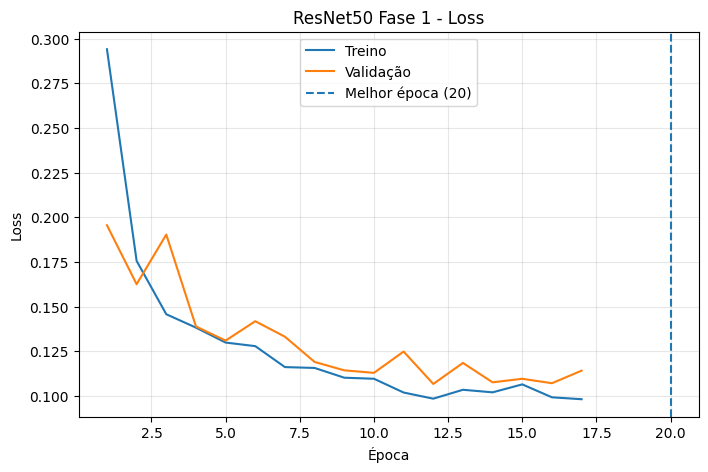

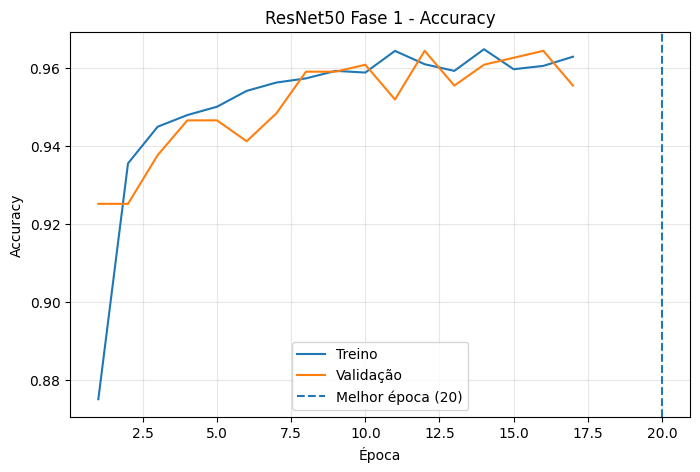

In [19]:
import matplotlib.pyplot as plt

# Loss
plt.figure(figsize=(8, 5))

plt.plot(
    historico_df_resnet["epoca"],
    historico_df_resnet["loss"],
    label="Treino"
)

plt.plot(
    historico_df_resnet["epoca"],
    historico_df_resnet["val_loss"],
    label="Validação"
)

plt.axvline(
    x=20,
    linestyle="--",
    label="Melhor época (20)"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("ResNet50 Fase 1 - Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    historico_df_resnet["epoca"],
    historico_df_resnet["accuracy"],
    label="Treino"
)

plt.plot(
    historico_df_resnet["epoca"],
    historico_df_resnet["val_accuracy"],
    label="Validação"
)

plt.axvline(
    x=20,
    linestyle="--",
    label="Melhor época (20)"
)

plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("ResNet50 Fase 1 - Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

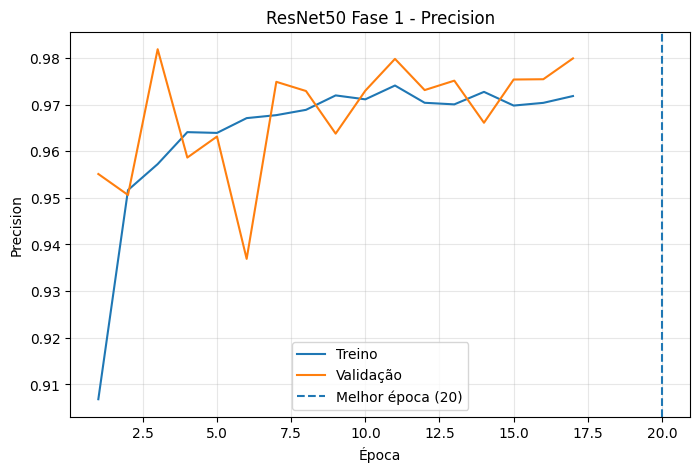

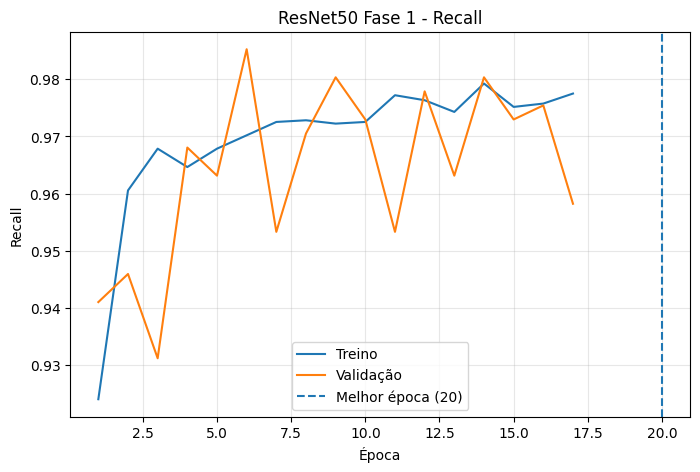

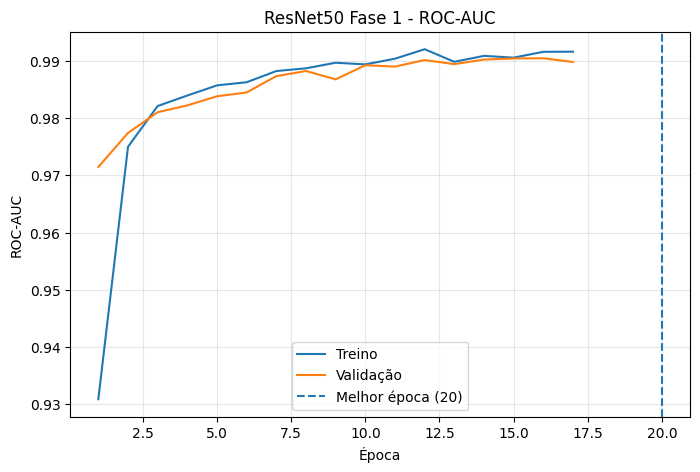

In [20]:
# Precision
plt.figure(figsize=(8, 5))

plt.plot(
    historico_df_resnet["epoca"],
    historico_df_resnet["precision"],
    label="Treino"
)

plt.plot(
    historico_df_resnet["epoca"],
    historico_df_resnet["val_precision"],
    label="Validação"
)

plt.axvline(
    x=20,
    linestyle="--",
    label="Melhor época (20)"
)

plt.xlabel("Época")
plt.ylabel("Precision")
plt.title("ResNet50 Fase 1 - Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Recall
plt.figure(figsize=(8, 5))

plt.plot(
    historico_df_resnet["epoca"],
    historico_df_resnet["recall"],
    label="Treino"
)

plt.plot(
    historico_df_resnet["epoca"],
    historico_df_resnet["val_recall"],
    label="Validação"
)

plt.axvline(
    x=20,
    linestyle="--",
    label="Melhor época (20)"
)

plt.xlabel("Época")
plt.ylabel("Recall")
plt.title("ResNet50 Fase 1 - Recall")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ROC-AUC
plt.figure(figsize=(8, 5))

plt.plot(
    historico_df_resnet["epoca"],
    historico_df_resnet["roc_auc"],
    label="Treino"
)

plt.plot(
    historico_df_resnet["epoca"],
    historico_df_resnet["val_roc_auc"],
    label="Validação"
)

plt.axvline(
    x=20,
    linestyle="--",
    label="Melhor época (20)"
)

plt.xlabel("Época")
plt.ylabel("ROC-AUC")
plt.title("ResNet50 Fase 1 - ROC-AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [21]:
CAMINHO_HISTORICO_RESNET = (
    "/kaggle/working/"
    "historico_treinamento_resnet50_fase1.csv"
)

historico_df_resnet.to_csv(
    CAMINHO_HISTORICO_RESNET,
    index=False
)

historico_reaberto = pd.read_csv(
    CAMINHO_HISTORICO_RESNET
)

print("Arquivo salvo em:")
print(CAMINHO_HISTORICO_RESNET)

print("\nDimensão:", historico_reaberto.shape)

print(
    "Melhor época após reabrir:",
    int(
        historico_reaberto.loc[
            historico_reaberto["val_loss"].idxmin(),
            "epoca"
        ]
    )
)

print(
    "Melhor val_loss após reabrir:",
    historico_reaberto["val_loss"].min()
)

Arquivo salvo em:
/kaggle/working/historico_treinamento_resnet50_fase1.csv

Dimensão: (17, 11)
Melhor época após reabrir: 12
Melhor val_loss após reabrir: 0.1066924631595611


In [22]:
modelo_resnet_best = tf.keras.models.load_model(
    CAMINHO_MODELO_RESNET
)

parametros_treinaveis_best = sum(
    tf.keras.backend.count_params(p)
    for p in modelo_resnet_best.trainable_weights
)

print("Melhor modelo recarregado com sucesso.")

print("\nNome do modelo:")
print(modelo_resnet_best.name)

print("\nParâmetros totais:")
print(modelo_resnet_best.count_params())

print("\nParâmetros treináveis:")
print(parametros_treinaveis_best)

print("\nFormato da entrada:")
print(modelo_resnet_best.input_shape)

print("\nFormato da saída:")
print(modelo_resnet_best.output_shape)

Melhor modelo recarregado com sucesso.

Nome do modelo:
resnet50_transfer_learning

Parâmetros totais:
23589761

Parâmetros treináveis:
2049

Formato da entrada:
(None, 224, 224, 3)

Formato da saída:
(None, 1)


In [23]:
resultados_teste_resnet = modelo_resnet_best.evaluate(
    ds_teste,
    verbose=1,
    return_dict=True
)

print("\n=== RESULTADOS OFICIAIS NO TESTE ===")

for metrica, valor in resultados_teste_resnet.items():
    print(f"{metrica}: {valor:.6f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - accuracy: 0.9656 - loss: 0.0901 - precision: 0.9736 - recall: 0.9783 - roc_auc: 0.9943

=== RESULTADOS OFICIAIS NO TESTE ===
accuracy: 0.965577
loss: 0.090117
precision: 0.973621
recall: 0.978313
roc_auc: 0.994288


In [24]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Probabilidades produzidas pela ResNet50
probabilidades_resnet = modelo_resnet_best.predict(
    ds_teste,
    verbose=1
).ravel()

# Rótulos verdadeiros na mesma ordem do ds_teste
y_true_resnet = df_teste["label"].to_numpy()

# Threshold oficial
THRESHOLD = 0.5

y_pred_resnet = (
    probabilidades_resnet >= THRESHOLD
).astype(int)

# Métricas
accuracy_resnet = accuracy_score(
    y_true_resnet,
    y_pred_resnet
)

precision_resnet = precision_score(
    y_true_resnet,
    y_pred_resnet
)

recall_resnet = recall_score(
    y_true_resnet,
    y_pred_resnet
)

f1_resnet = f1_score(
    y_true_resnet,
    y_pred_resnet
)

roc_auc_resnet = roc_auc_score(
    y_true_resnet,
    probabilidades_resnet
)

matriz_resnet = confusion_matrix(
    y_true_resnet,
    y_pred_resnet
)

print("=== MÉTRICAS SCIKIT-LEARN ===")

print(f"Accuracy:  {accuracy_resnet:.6f}")
print(f"Precision: {precision_resnet:.6f}")
print(f"Recall:    {recall_resnet:.6f}")
print(f"F1-score:  {f1_resnet:.6f}")
print(f"ROC-AUC:   {roc_auc_resnet:.6f}")

print("\nMatriz de confusão:")
print(matriz_resnet)

print("\nTotal de previsões:", len(probabilidades_resnet))
print(
    "Probabilidade mínima:",
    probabilidades_resnet.min()
)
print(
    "Probabilidade máxima:",
    probabilidades_resnet.max()
)

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step
=== MÉTRICAS SCIKIT-LEARN ===
Accuracy:  0.965577
Precision: 0.973621
Recall:    0.978313
F1-score:  0.975962
ROC-AUC:   0.994324

Matriz de confusão:
[[155  11]
 [  9 406]]

Total de previsões: 581
Probabilidade mínima: 4.560128e-05
Probabilidade máxima: 0.99999857


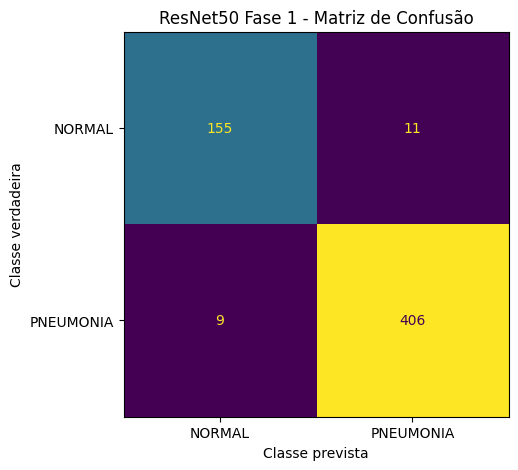

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

display_resnet = ConfusionMatrixDisplay(
    confusion_matrix=matriz_resnet,
    display_labels=["NORMAL", "PNEUMONIA"]
)

fig, ax = plt.subplots(figsize=(6, 5))

display_resnet.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

ax.set_title("ResNet50 Fase 1 - Matriz de Confusão")
ax.set_xlabel("Classe prevista")
ax.set_ylabel("Classe verdadeira")

plt.show()

In [26]:
analise_teste_resnet = df_teste.copy().reset_index(drop=True)

analise_teste_resnet["probabilidade_pneumonia"] = probabilidades_resnet
analise_teste_resnet["classe_prevista_num"] = y_pred_resnet

analise_teste_resnet["classe_prevista"] = np.where(
    analise_teste_resnet["classe_prevista_num"] == 1,
    "PNEUMONIA",
    "NORMAL"
)

analise_teste_resnet["acerto"] = (
    analise_teste_resnet["label"]
    == analise_teste_resnet["classe_prevista_num"]
)

analise_teste_resnet["tipo_resultado"] = np.select(
    [
        (analise_teste_resnet["label"] == 0)
        & (analise_teste_resnet["classe_prevista_num"] == 0),

        (analise_teste_resnet["label"] == 0)
        & (analise_teste_resnet["classe_prevista_num"] == 1),

        (analise_teste_resnet["label"] == 1)
        & (analise_teste_resnet["classe_prevista_num"] == 0),

        (analise_teste_resnet["label"] == 1)
        & (analise_teste_resnet["classe_prevista_num"] == 1)
    ],
    [
        "TN",
        "FP",
        "FN",
        "TP"
    ],
    default="INDEFINIDO"
)

print("Dimensão:", analise_teste_resnet.shape)

print("\nDistribuição dos resultados:")
print(
    analise_teste_resnet["tipo_resultado"]
    .value_counts()
)

print(
    "\nTotal de erros:",
    (~analise_teste_resnet["acerto"]).sum()
)

print(
    "\nResultados indefinidos:",
    (analise_teste_resnet["tipo_resultado"] == "INDEFINIDO").sum()
)

print("\nPrimeiras linhas:")
print(
    analise_teste_resnet[
        [
            "nome_arquivo",
            "classe",
            "probabilidade_pneumonia",
            "classe_prevista",
            "tipo_resultado"
        ]
    ].head()
)

Dimensão: (581, 17)

Distribuição dos resultados:
tipo_resultado
TP    406
TN    155
FP     11
FN      9
Name: count, dtype: int64

Total de erros: 20

Resultados indefinidos: 0

Primeiras linhas:
        nome_arquivo  classe  probabilidade_pneumonia classe_prevista  \
0  IM-0119-0001.jpeg  NORMAL                 0.001629          NORMAL   
1  IM-0135-0001.jpeg  NORMAL                 0.001679          NORMAL   
2  IM-0137-0001.jpeg  NORMAL                 0.069663          NORMAL   
3  IM-0156-0001.jpeg  NORMAL                 0.058300          NORMAL   
4  IM-0172-0001.jpeg  NORMAL                 0.006792          NORMAL   

  tipo_resultado  
0             TN  
1             TN  
2             TN  
3             TN  
4             TN  


In [27]:
erros_fp_resnet = analise_teste_resnet[
    analise_teste_resnet["tipo_resultado"] == "FP"
].copy()

erros_fn_resnet = analise_teste_resnet[
    analise_teste_resnet["tipo_resultado"] == "FN"
].copy()

print("=== FALSOS POSITIVOS ===")
print("Quantidade:", len(erros_fp_resnet))

print(
    "Média:",
    erros_fp_resnet["probabilidade_pneumonia"].mean()
)

print(
    "Mediana:",
    erros_fp_resnet["probabilidade_pneumonia"].median()
)

print(
    "Mínimo:",
    erros_fp_resnet["probabilidade_pneumonia"].min()
)

print(
    "Máximo:",
    erros_fp_resnet["probabilidade_pneumonia"].max()
)


print("\n=== FALSOS NEGATIVOS ===")
print("Quantidade:", len(erros_fn_resnet))

print(
    "Média:",
    erros_fn_resnet["probabilidade_pneumonia"].mean()
)

print(
    "Mediana:",
    erros_fn_resnet["probabilidade_pneumonia"].median()
)

print(
    "Mínimo:",
    erros_fn_resnet["probabilidade_pneumonia"].min()
)

print(
    "Máximo:",
    erros_fn_resnet["probabilidade_pneumonia"].max()
)

=== FALSOS POSITIVOS ===
Quantidade: 11
Média: 0.73942417
Mediana: 0.7137711048126221
Mínimo: 0.5258594155311584
Máximo: 0.9452270865440369

=== FALSOS NEGATIVOS ===
Quantidade: 9
Média: 0.21309942
Mediana: 0.15301404893398285
Mínimo: 0.07569237798452377
Máximo: 0.4149933457374573


In [28]:
fp_extremos_resnet = (
    erros_fp_resnet
    .sort_values(
        "probabilidade_pneumonia",
        ascending=False
    )
    .head(3)
)

fn_extremos_resnet = (
    erros_fn_resnet
    .sort_values(
        "probabilidade_pneumonia",
        ascending=True
    )
    .head(3)
)

print("=== 3 FALSOS POSITIVOS MAIS EXTREMOS ===")

print(
    fp_extremos_resnet[
        [
            "nome_arquivo",
            "classe",
            "probabilidade_pneumonia"
        ]
    ].to_string(index=False)
)

print("\n=== 3 FALSOS NEGATIVOS MAIS EXTREMOS ===")

print(
    fn_extremos_resnet[
        [
            "nome_arquivo",
            "classe",
            "probabilidade_pneumonia"
        ]
    ].to_string(index=False)
)

=== 3 FALSOS POSITIVOS MAIS EXTREMOS ===
             nome_arquivo classe  probabilidade_pneumonia
NORMAL2-IM-0330-0001.jpeg NORMAL                 0.945227
NORMAL2-IM-0316-0001.jpeg NORMAL                 0.928277
NORMAL2-IM-0222-0001.jpeg NORMAL                 0.912148

=== 3 FALSOS NEGATIVOS MAIS EXTREMOS ===
              nome_arquivo    classe  probabilidade_pneumonia
person1164_virus_1956.jpeg PNEUMONIA                 0.075692
  person435_virus_885.jpeg PNEUMONIA                 0.108520
  person277_virus_571.jpeg PNEUMONIA                 0.120061


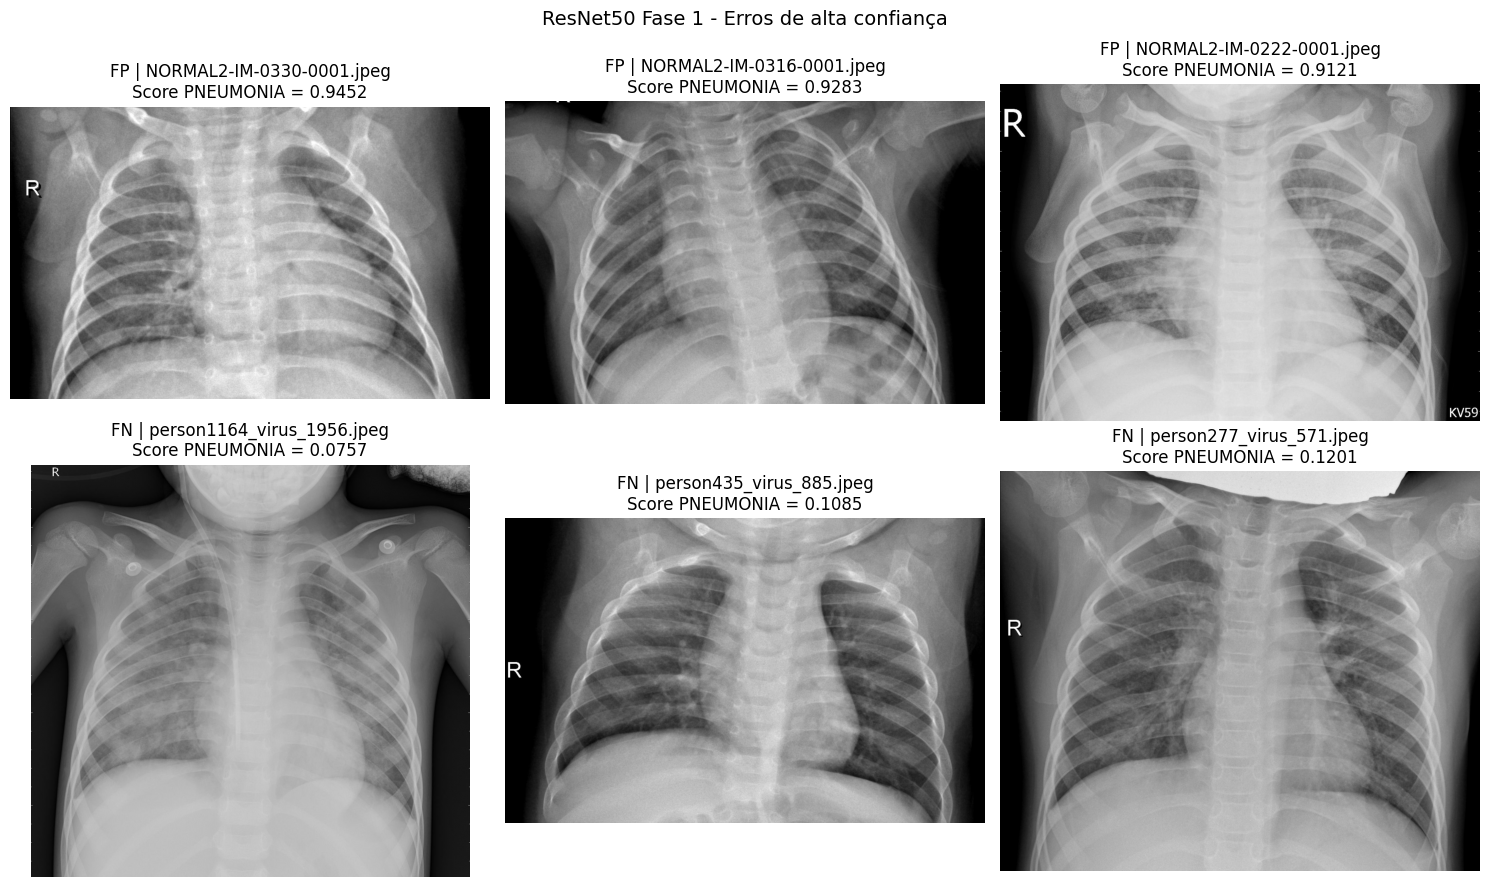

In [29]:
from PIL import Image

casos_extremos_resnet = pd.concat(
    [
        fp_extremos_resnet,
        fn_extremos_resnet
    ],
    ignore_index=True
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

axes = axes.ravel()

for ax, (_, linha) in zip(
    axes,
    casos_extremos_resnet.iterrows()
):
    imagem = Image.open(
        linha["caminho"]
    ).convert("L")

    ax.imshow(
        imagem,
        cmap="gray"
    )

    ax.set_title(
        f'{linha["tipo_resultado"]} | '
        f'{linha["nome_arquivo"]}\n'
        f'Score PNEUMONIA = '
        f'{linha["probabilidade_pneumonia"]:.4f}'
    )

    ax.axis("off")

plt.suptitle(
    "ResNet50 Fase 1 - Erros de alta confiança",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [30]:
def obter_dimensoes_originais(caminho):
    with Image.open(caminho) as img:
        largura, altura = img.size

    return largura, altura


dimensoes_teste = analise_teste_resnet["caminho"].apply(
    obter_dimensoes_originais
)

analise_teste_resnet["largura_original"] = [
    largura for largura, altura in dimensoes_teste
]

analise_teste_resnet["altura_original"] = [
    altura for largura, altura in dimensoes_teste
]

analise_teste_resnet["razao_aspecto"] = (
    analise_teste_resnet["largura_original"]
    / analise_teste_resnet["altura_original"]
)

analise_teste_resnet["pixels_totais"] = (
    analise_teste_resnet["largura_original"]
    * analise_teste_resnet["altura_original"]
)

print("Imagens processadas:", len(analise_teste_resnet))

print(
    "Valores ausentes nas dimensões:",
    analise_teste_resnet[
        [
            "largura_original",
            "altura_original",
            "razao_aspecto",
            "pixels_totais"
        ]
    ].isna().sum().sum()
)

print("\nPrimeiras linhas:")
print(
    analise_teste_resnet[
        [
            "nome_arquivo",
            "largura_original",
            "altura_original",
            "razao_aspecto",
            "pixels_totais"
        ]
    ].head()
)

Imagens processadas: 581
Valores ausentes nas dimensões: 0

Primeiras linhas:
        nome_arquivo  largura_original  altura_original  razao_aspecto  \
0  IM-0119-0001.jpeg              1810             1434       1.262204   
1  IM-0135-0001.jpeg              1724             1581       1.090449   
2  IM-0137-0001.jpeg              1346             1044       1.289272   
3  IM-0156-0001.jpeg              1488             1209       1.230769   
4  IM-0172-0001.jpeg              1876             1893       0.991020   

   pixels_totais  
0        2595540  
1        2725644  
2        1405224  
3        1798992  
4        3551268  


In [31]:
resumo_tecnico_resnet = (
    analise_teste_resnet
    .groupby(
        ["classe", "acerto"]
    )[
        [
            "largura_original",
            "altura_original",
            "razao_aspecto",
            "pixels_totais"
        ]
    ]
    .median()
    .reset_index()
)

resumo_tecnico_resnet["resultado"] = np.where(
    resumo_tecnico_resnet["acerto"],
    "ACERTO",
    "ERRO"
)

resumo_tecnico_resnet = resumo_tecnico_resnet[
    [
        "classe",
        "resultado",
        "largura_original",
        "altura_original",
        "razao_aspecto",
        "pixels_totais"
    ]
]

print("=== MEDIANAS POR CLASSE E ACERTO/ERRO ===")
print(
    resumo_tecnico_resnet.to_string(
        index=False
    )
)

=== MEDIANAS POR CLASSE E ACERTO/ERRO ===
   classe resultado  largura_original  altura_original  razao_aspecto  pixels_totais
   NORMAL      ERRO            1554.0           1168.0       1.274648      1737984.0
   NORMAL    ACERTO            1724.0           1392.0       1.217054      2372692.0
PNEUMONIA      ERRO            1766.0           1380.0       1.258731      2453640.0
PNEUMONIA    ACERTO            1152.0            776.0       1.505573       896212.0


<Figure size 1000x500 with 0 Axes>

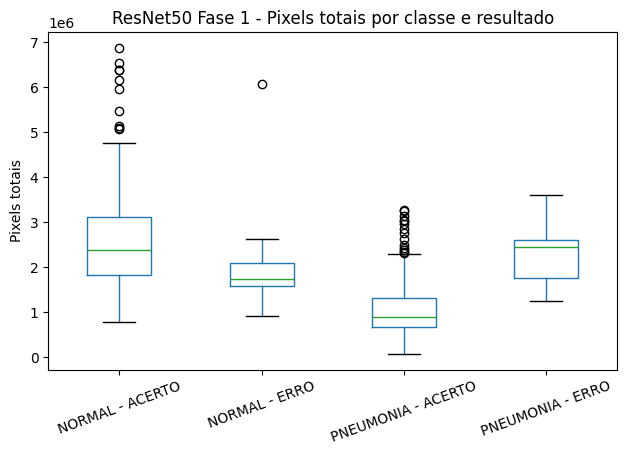

<Figure size 1000x500 with 0 Axes>

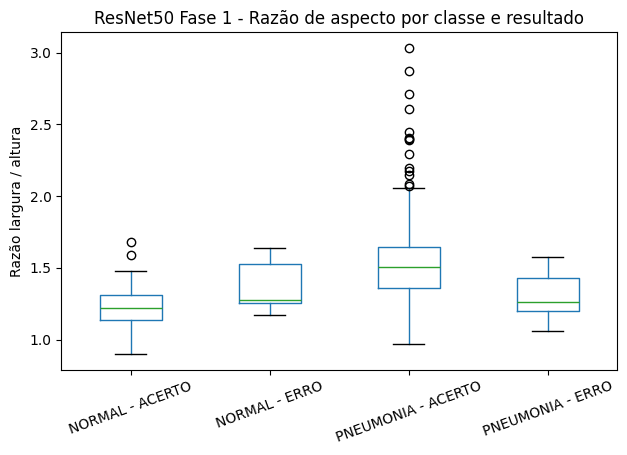

In [32]:
analise_teste_resnet["grupo_resultado"] = (
    analise_teste_resnet["classe"]
    + " - "
    + np.where(
        analise_teste_resnet["acerto"],
        "ACERTO",
        "ERRO"
    )
)

# Pixels totais
plt.figure(figsize=(10, 5))

analise_teste_resnet.boxplot(
    column="pixels_totais",
    by="grupo_resultado",
    grid=False,
    rot=20
)

plt.title("ResNet50 Fase 1 - Pixels totais por classe e resultado")
plt.suptitle("")
plt.xlabel("")
plt.ylabel("Pixels totais")
plt.tight_layout()
plt.show()


# Razão de aspecto
plt.figure(figsize=(10, 5))

analise_teste_resnet.boxplot(
    column="razao_aspecto",
    by="grupo_resultado",
    grid=False,
    rot=20
)

plt.title("ResNet50 Fase 1 - Razão de aspecto por classe e resultado")
plt.suptitle("")
plt.xlabel("")
plt.ylabel("Razão largura / altura")
plt.tight_layout()
plt.show()

In [33]:
CAMINHO_ANALISE_RESNET = (
    "/kaggle/working/"
    "analise_teste_resnet50_fase1.csv"
)

analise_teste_resnet.to_csv(
    CAMINHO_ANALISE_RESNET,
    index=False
)

analise_resnet_reaberta = pd.read_csv(
    CAMINHO_ANALISE_RESNET
)

print("Arquivo salvo em:")
print(CAMINHO_ANALISE_RESNET)

print("\nDimensão:", analise_resnet_reaberta.shape)

print(
    "Total de erros preservados:",
    (~analise_resnet_reaberta["acerto"]).sum()
)

print(
    "Probabilidades ausentes:",
    analise_resnet_reaberta[
        "probabilidade_pneumonia"
    ].isna().sum()
)

print("\nDistribuição preservada:")
print(
    analise_resnet_reaberta[
        "tipo_resultado"
    ].value_counts()
)

Arquivo salvo em:
/kaggle/working/analise_teste_resnet50_fase1.csv

Dimensão: (581, 22)
Total de erros preservados: 20
Probabilidades ausentes: 0

Distribuição preservada:
tipo_resultado
TP    406
TN    155
FP     11
FN      9
Name: count, dtype: int64


In [34]:
resumo_resnet_fase1 = pd.DataFrame(
    [
        ["modelo", "ResNet50 Transfer Learning - Fase 1"],
        ["pesos_pre_treinados", "ImageNet"],
        ["base_convolucional", "ResNet50"],
        ["base_congelada", True],
        ["fine_tuning", False],
        ["data_augmentation", False],
        ["class_weight", False],
        ["preprocessamento", "resnet50.preprocess_input"],
        ["tamanho_entrada", "224x224x3"],
        ["batch_size", BATCH_SIZE],
        ["seed", SEED],
        ["optimizer", "Adam"],
        ["learning_rate", 0.001],
        ["loss", "BinaryCrossentropy"],
        ["epocas_maximas", EPOCHS],
        ["epocas_executadas", len(historico_df_resnet)],
        ["melhor_epoca", int(melhor_resultado["epoca"])],
        ["melhor_val_loss", float(melhor_resultado["val_loss"])],
        ["parametros_totais", modelo_resnet_best.count_params()],
        ["parametros_treinaveis", 2049],
        ["parametros_nao_treinaveis", 23587712],
        ["teste_n", len(df_teste)],
        ["teste_loss", float(resultados_teste_resnet["loss"])],
        ["teste_accuracy", accuracy_resnet],
        ["teste_precision", precision_resnet],
        ["teste_recall", recall_resnet],
        ["teste_f1", f1_resnet],
        ["teste_roc_auc_sklearn", roc_auc_resnet],
        ["teste_roc_auc_keras", float(resultados_teste_resnet["roc_auc"])],
        ["tn", int(matriz_resnet[0, 0])],
        ["fp", int(matriz_resnet[0, 1])],
        ["fn", int(matriz_resnet[1, 0])],
        ["tp", int(matriz_resnet[1, 1])],
        ["erros_totais", int((~analise_teste_resnet["acerto"]).sum())]
    ],
    columns=["metrica", "valor"]
)

CAMINHO_RESUMO_RESNET = (
    "/kaggle/working/"
    "resumo_resultados_resnet50_fase1.csv"
)

resumo_resnet_fase1.to_csv(
    CAMINHO_RESUMO_RESNET,
    index=False
)

resumo_resnet_reaberto = pd.read_csv(
    CAMINHO_RESUMO_RESNET
)

print("Arquivo salvo em:")
print(CAMINHO_RESUMO_RESNET)

print("\nDimensão:", resumo_resnet_reaberto.shape)

print("\nResumo:")
print(resumo_resnet_reaberto.to_string(index=False))

Arquivo salvo em:
/kaggle/working/resumo_resultados_resnet50_fase1.csv

Dimensão: (34, 2)

Resumo:
                  metrica                               valor
                   modelo ResNet50 Transfer Learning - Fase 1
      pesos_pre_treinados                            ImageNet
       base_convolucional                            ResNet50
           base_congelada                                True
              fine_tuning                               False
        data_augmentation                               False
             class_weight                               False
         preprocessamento           resnet50.preprocess_input
          tamanho_entrada                           224x224x3
               batch_size                                  32
                     seed                                  42
                optimizer                                Adam
            learning_rate                               0.001
                     loss        

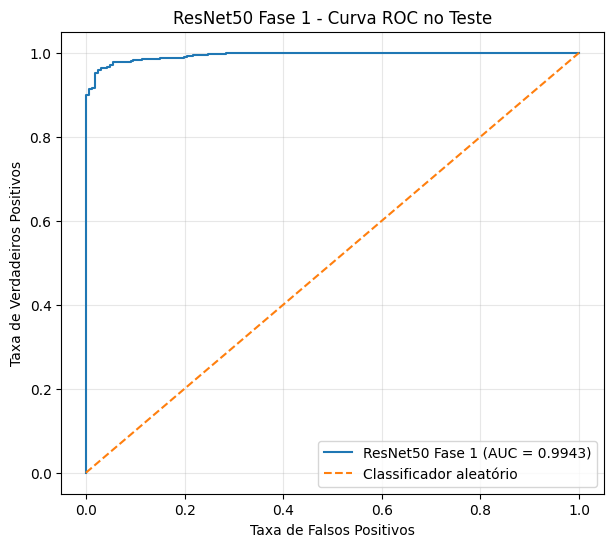

In [35]:
from sklearn.metrics import roc_curve

fpr_resnet, tpr_resnet, thresholds_resnet = roc_curve(
    y_true_resnet,
    probabilidades_resnet
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_resnet,
    tpr_resnet,
    label=f"ResNet50 Fase 1 (AUC = {roc_auc_resnet:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificador aleatório"
)

plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("ResNet50 Fase 1 - Curva ROC no Teste")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [36]:
comparacao_modelos = pd.DataFrame({
    "Métrica": [
        "Loss",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "TN",
        "FP",
        "FN",
        "TP",
        "Erros totais"
    ],
    "CNN baseline": [
        0.1296,
        0.948365,
        0.961631,
        0.966265,
        0.963942,
        0.987981,
        150,
        16,
        14,
        401,
        30
    ],
    "ResNet50 Fase 1": [
        resultados_teste_resnet["loss"],
        accuracy_resnet,
        precision_resnet,
        recall_resnet,
        f1_resnet,
        roc_auc_resnet,
        matriz_resnet[0, 0],
        matriz_resnet[0, 1],
        matriz_resnet[1, 0],
        matriz_resnet[1, 1],
        (~analise_teste_resnet["acerto"]).sum()
    ]
})

print("=== COMPARAÇÃO OFICIAL NO TESTE ===")
print(comparacao_modelos.to_string(index=False))

=== COMPARAÇÃO OFICIAL NO TESTE ===
     Métrica  CNN baseline  ResNet50 Fase 1
        Loss      0.129600         0.090117
    Accuracy      0.948365         0.965577
   Precision      0.961631         0.973621
      Recall      0.966265         0.978313
    F1-score      0.963942         0.975962
     ROC-AUC      0.987981         0.994324
          TN    150.000000       155.000000
          FP     16.000000        11.000000
          FN     14.000000         9.000000
          TP    401.000000       406.000000
Erros totais     30.000000        20.000000


In [37]:
ganhos_resnet = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "CNN": [
        0.948365,
        0.961631,
        0.966265,
        0.963942,
        0.987981
    ],
    "ResNet50": [
        accuracy_resnet,
        precision_resnet,
        recall_resnet,
        f1_resnet,
        roc_auc_resnet
    ]
})

ganhos_resnet["Diferença absoluta"] = (
    ganhos_resnet["ResNet50"]
    - ganhos_resnet["CNN"]
)

ganhos_resnet["Diferença em p.p."] = (
    ganhos_resnet["Diferença absoluta"] * 100
)

reducao_erros_pct = (
    (30 - 19) / 30
) * 100

reducao_fp_pct = (
    (16 - 9) / 16
) * 100

reducao_fn_pct = (
    (14 - 10) / 14
) * 100

print("=== GANHOS DA RESNET50 SOBRE A CNN ===")
print(
    ganhos_resnet[
        [
            "Métrica",
            "Diferença em p.p."
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)

print(
    f"\nRedução relativa de erros totais: "
    f"{reducao_erros_pct:.2f}%"
)

print(
    f"Redução relativa de falsos positivos: "
    f"{reducao_fp_pct:.2f}%"
)

print(
    f"Redução relativa de falsos negativos: "
    f"{reducao_fn_pct:.2f}%"
)

=== GANHOS DA RESNET50 SOBRE A CNN ===
  Métrica  Diferença em p.p.
 Accuracy              1.721
Precision              1.199
   Recall              1.205
 F1-score              1.202
  ROC-AUC              0.634

Redução relativa de erros totais: 36.67%
Redução relativa de falsos positivos: 43.75%
Redução relativa de falsos negativos: 28.57%


In [38]:
CAMINHO_COMPARACAO = (
    "/kaggle/working/"
    "comparacao_cnn_resnet50.csv"
)

CAMINHO_GANHOS = (
    "/kaggle/working/"
    "ganhos_resnet50_sobre_cnn.csv"
)

comparacao_modelos.to_csv(
    CAMINHO_COMPARACAO,
    index=False
)

ganhos_resnet.to_csv(
    CAMINHO_GANHOS,
    index=False
)

comparacao_reaberta = pd.read_csv(
    CAMINHO_COMPARACAO
)

ganhos_reabertos = pd.read_csv(
    CAMINHO_GANHOS
)

print("Comparação salva:")
print(CAMINHO_COMPARACAO)
print("Dimensão:", comparacao_reaberta.shape)

print("\nGanhos salvos:")
print(CAMINHO_GANHOS)
print("Dimensão:", ganhos_reabertos.shape)

print("\nErros CNN preservados:")
print(
    comparacao_reaberta.loc[
        comparacao_reaberta["Métrica"] == "Erros totais",
        "CNN baseline"
    ].iloc[0]
)

print("Erros ResNet50 preservados:")
print(
    comparacao_reaberta.loc[
        comparacao_reaberta["Métrica"] == "Erros totais",
        "ResNet50 Fase 1"
    ].iloc[0]
)

Comparação salva:
/kaggle/working/comparacao_cnn_resnet50.csv
Dimensão: (11, 3)

Ganhos salvos:
/kaggle/working/ganhos_resnet50_sobre_cnn.csv
Dimensão: (5, 5)

Erros CNN preservados:
30.0
Erros ResNet50 preservados:
20.0


In [39]:
import os

NOME_ARQUIVO_CNN = "analise_teste_cnn_baseline.csv"

caminhos_encontrados = []

for raiz, pastas, arquivos in os.walk("/kaggle/input"):
    if NOME_ARQUIVO_CNN in arquivos:
        caminhos_encontrados.append(
            os.path.join(raiz, NOME_ARQUIVO_CNN)
        )

print("Quantidade de arquivos encontrados:", len(caminhos_encontrados))

for caminho in caminhos_encontrados:
    print(caminho)

Quantidade de arquivos encontrados: 1
/kaggle/input/notebooks/monicalanjos071829/03-cnn-baseline-pneumonia/analise_teste_cnn_baseline.csv


In [40]:
CAMINHO_ANALISE_CNN = caminhos_encontrados[0]

analise_teste_cnn = pd.read_csv(
    CAMINHO_ANALISE_CNN
)

print("Arquivo carregado:")
print(CAMINHO_ANALISE_CNN)

print("\nDimensão:")
print(analise_teste_cnn.shape)

print("\nColunas:")
print(analise_teste_cnn.columns.tolist())

if "acerto" in analise_teste_cnn.columns:
    print(
        "\nErros preservados:",
        (~analise_teste_cnn["acerto"]).sum()
    )

print("\nPrimeiras linhas:")
print(analise_teste_cnn.head(3))

Arquivo carregado:
/kaggle/input/notebooks/monicalanjos071829/03-cnn-baseline-pneumonia/analise_teste_cnn_baseline.csv

Dimensão:
(581, 21)

Colunas:
['caminho', 'nome_arquivo', 'divisao_original', 'classe', 'extensao', 'sha256', 'grupo_candidato', 'duplicata_exata', 'copia_excedente', 'fold', 'divisao_nova', 'rotulo', 'probabilidade_pneumonia', 'rotulo_previsto', 'classe_prevista', 'erro', 'largura', 'altura', 'razao_aspecto', 'pixels_totais', 'resultado_classificacao']

Primeiras linhas:
                                             caminho       nome_arquivo  \
0  /kaggle/input/datasets/paultimothymooney/chest...  IM-0119-0001.jpeg   
1  /kaggle/input/datasets/paultimothymooney/chest...  IM-0135-0001.jpeg   
2  /kaggle/input/datasets/paultimothymooney/chest...  IM-0137-0001.jpeg   

  divisao_original  classe extensao  \
0            train  NORMAL    .jpeg   
1            train  NORMAL    .jpeg   
2            train  NORMAL    .jpeg   

                                              s

In [41]:
print("Total de imagens CNN:", len(analise_teste_cnn))

print(
    "Total de erros CNN:",
    analise_teste_cnn["erro"].sum()
)

print("\nDistribuição do resultado:")
print(
    analise_teste_cnn[
        "resultado_classificacao"
    ].value_counts()
)

print(
    "\nProbabilidades ausentes:",
    analise_teste_cnn[
        "probabilidade_pneumonia"
    ].isna().sum()
)

Total de imagens CNN: 581
Total de erros CNN: 31

Distribuição do resultado:
resultado_classificacao
ACERTO    550
ERRO       31
Name: count, dtype: int64

Probabilidades ausentes: 0


In [42]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_true_cnn_csv = (
    analise_teste_cnn["rotulo"]
    .astype(int)
    .to_numpy()
)

y_pred_cnn_csv = (
    analise_teste_cnn["rotulo_previsto"]
    .astype(int)
    .to_numpy()
)

y_prob_cnn_csv = (
    analise_teste_cnn["probabilidade_pneumonia"]
    .astype(float)
    .to_numpy()
)

erros_recalculados_cnn = (
    y_true_cnn_csv != y_pred_cnn_csv
)

matriz_cnn_csv = confusion_matrix(
    y_true_cnn_csv,
    y_pred_cnn_csv
)

print("=== AUDITORIA DO ARTEFATO CNN ===")

print("\nErros pela coluna 'erro':")
print(int(analise_teste_cnn["erro"].sum()))

print("\nErros recalculados por rótulo verdadeiro != previsto:")
print(int(erros_recalculados_cnn.sum()))

print("\nMatriz de confusão recalculada:")
print(matriz_cnn_csv)

print("\nMétricas recalculadas:")
print(
    "Accuracy:",
    accuracy_score(y_true_cnn_csv, y_pred_cnn_csv)
)
print(
    "Precision:",
    precision_score(y_true_cnn_csv, y_pred_cnn_csv)
)
print(
    "Recall:",
    recall_score(y_true_cnn_csv, y_pred_cnn_csv)
)
print(
    "F1-score:",
    f1_score(y_true_cnn_csv, y_pred_cnn_csv)
)
print(
    "ROC-AUC:",
    roc_auc_score(y_true_cnn_csv, y_prob_cnn_csv)
)

print("\nDistribuição verdadeira:")
print(
    analise_teste_cnn["rotulo"]
    .value_counts()
    .sort_index()
)

print("\nDistribuição prevista:")
print(
    analise_teste_cnn["rotulo_previsto"]
    .value_counts()
    .sort_index()
)

=== AUDITORIA DO ARTEFATO CNN ===

Erros pela coluna 'erro':
31

Erros recalculados por rótulo verdadeiro != previsto:
31

Matriz de confusão recalculada:
[[146  20]
 [ 11 404]]

Métricas recalculadas:
Accuracy: 0.9466437177280551
Precision: 0.9528301886792453
Recall: 0.9734939759036144
F1-score: 0.9630512514898689
ROC-AUC: 0.9891856582958339

Distribuição verdadeira:
rotulo
0    166
1    415
Name: count, dtype: int64

Distribuição prevista:
rotulo_previsto
0    157
1    424
Name: count, dtype: int64


In [43]:
PASTA_CNN = os.path.dirname(CAMINHO_ANALISE_CNN)

print("=== ARQUIVOS NO OUTPUT DA CNN ===")
for arquivo in sorted(os.listdir(PASTA_CNN)):
    print(arquivo)

CAMINHO_RESUMO_CNN = os.path.join(
    PASTA_CNN,
    "resumo_resultados_cnn_baseline.csv"
)

print("\nResumo existe:", os.path.exists(CAMINHO_RESUMO_CNN))

if os.path.exists(CAMINHO_RESUMO_CNN):
    resumo_cnn_auditado = pd.read_csv(CAMINHO_RESUMO_CNN)

    print("\n=== RESUMO CNN DO MESMO OUTPUT ===")
    print(resumo_cnn_auditado.to_string(index=False))

=== ARQUIVOS NO OUTPUT DA CNN ===
__notebook__.ipynb
__output__.json
__results__.html
__results___files
analise_teste_cnn_baseline.csv
cnn_baseline_best.keras
custom.css
historico_treinamento_cnn_baseline.csv
resumo_resultados_cnn_baseline.csv

Resumo existe: True

=== RESUMO CNN DO MESMO OUTPUT ===
                 item               valor
               modelo        CNN baseline
       altura_entrada                 224
      largura_entrada                 224
               canais                   3
           batch_size                  32
                 seed                  42
parametros_treinaveis              421441
            optimizer                Adam
        learning_rate               0.001
                 loss  BinaryCrossentropy
       epocas_maximas                  30
    epocas_executadas                  21
         melhor_epoca                  16
      melhor_val_loss 0.15469224750995636
       accuracy_teste  0.9466437177280551
      precision_teste  0.95

In [44]:
from sklearn.metrics import log_loss

# Loss oficial reconstruída a partir das probabilidades preservadas
loss_cnn_oficial = log_loss(
    analise_teste_cnn["rotulo"].astype(int),
    analise_teste_cnn["probabilidade_pneumonia"].astype(float)
)

fp_cnn_oficial = analise_teste_cnn[
    (analise_teste_cnn["rotulo"] == 0)
    & (analise_teste_cnn["rotulo_previsto"] == 1)
].copy()

fn_cnn_oficial = analise_teste_cnn[
    (analise_teste_cnn["rotulo"] == 1)
    & (analise_teste_cnn["rotulo_previsto"] == 0)
].copy()

print("=== LOSS OFICIAL RECONSTRUÍDA ===")
print("Loss:", loss_cnn_oficial)


print("\n=== FALSOS POSITIVOS ===")
print("Quantidade:", len(fp_cnn_oficial))
print("Média:", fp_cnn_oficial["probabilidade_pneumonia"].mean())
print("Mediana:", fp_cnn_oficial["probabilidade_pneumonia"].median())
print("Mínimo:", fp_cnn_oficial["probabilidade_pneumonia"].min())
print("Máximo:", fp_cnn_oficial["probabilidade_pneumonia"].max())


print("\n=== FALSOS NEGATIVOS ===")
print("Quantidade:", len(fn_cnn_oficial))
print("Média:", fn_cnn_oficial["probabilidade_pneumonia"].mean())
print("Mediana:", fn_cnn_oficial["probabilidade_pneumonia"].median())
print("Mínimo:", fn_cnn_oficial["probabilidade_pneumonia"].min())
print("Máximo:", fn_cnn_oficial["probabilidade_pneumonia"].max())


print("\n=== 3 FP MAIS EXTREMOS ===")
print(
    fp_cnn_oficial
    .sort_values("probabilidade_pneumonia", ascending=False)
    [["nome_arquivo", "probabilidade_pneumonia"]]
    .head(3)
    .to_string(index=False)
)


print("\n=== 3 FN MAIS EXTREMOS ===")
print(
    fn_cnn_oficial
    .sort_values("probabilidade_pneumonia", ascending=True)
    [["nome_arquivo", "probabilidade_pneumonia"]]
    .head(3)
    .to_string(index=False)
)


print("\n=== MEDIANAS TÉCNICAS POR CLASSE E RESULTADO ===")

analise_teste_cnn["resultado_auditoria"] = np.where(
    analise_teste_cnn["erro"],
    "ERRO",
    "ACERTO"
)

resumo_tecnico_cnn_oficial = (
    analise_teste_cnn
    .groupby(["classe", "resultado_auditoria"])[
        ["largura", "altura", "razao_aspecto", "pixels_totais"]
    ]
    .median()
)

print(resumo_tecnico_cnn_oficial)

=== LOSS OFICIAL RECONSTRUÍDA ===
Loss: 0.1273181218889807

=== FALSOS POSITIVOS ===
Quantidade: 20
Média: 0.7513186229999999
Mediana: 0.73510721
Mínimo: 0.51165134
Máximo: 0.9847435

=== FALSOS NEGATIVOS ===
Quantidade: 11
Média: 0.317294701
Mediana: 0.3801372
Mínimo: 0.020320151
Máximo: 0.49783644

=== 3 FP MAIS EXTREMOS ===
             nome_arquivo  probabilidade_pneumonia
NORMAL2-IM-0259-0001.jpeg                 0.984743
NORMAL2-IM-0222-0001.jpeg                 0.968486
NORMAL2-IM-0229-0001.jpeg                 0.967477

=== 3 FN MAIS EXTREMOS ===
                nome_arquivo  probabilidade_pneumonia
    person277_virus_571.jpeg                 0.020320
person559_bacteria_2329.jpeg                 0.065294
   person703_virus_1300.jpeg                 0.079205

=== MEDIANAS TÉCNICAS POR CLASSE E RESULTADO ===
                               largura  altura  razao_aspecto  pixels_totais
classe    resultado_auditoria                                               
NORMAL    ACERTO   

In [45]:
from sklearn.metrics import (
    log_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# =========================================================
# CNN BASELINE — VERSION #1 SUCCESSFUL
# =========================================================

y_true_cnn_oficial = (
    analise_teste_cnn["rotulo"]
    .astype(int)
    .to_numpy()
)

y_pred_cnn_oficial = (
    analise_teste_cnn["rotulo_previsto"]
    .astype(int)
    .to_numpy()
)

y_prob_cnn_oficial = (
    analise_teste_cnn["probabilidade_pneumonia"]
    .astype(float)
    .to_numpy()
)

loss_cnn_oficial = log_loss(
    y_true_cnn_oficial,
    y_prob_cnn_oficial
)

accuracy_cnn_oficial = accuracy_score(
    y_true_cnn_oficial,
    y_pred_cnn_oficial
)

precision_cnn_oficial = precision_score(
    y_true_cnn_oficial,
    y_pred_cnn_oficial
)

recall_cnn_oficial = recall_score(
    y_true_cnn_oficial,
    y_pred_cnn_oficial
)

f1_cnn_oficial = f1_score(
    y_true_cnn_oficial,
    y_pred_cnn_oficial
)

roc_auc_cnn_oficial = roc_auc_score(
    y_true_cnn_oficial,
    y_prob_cnn_oficial
)

matriz_cnn_oficial = confusion_matrix(
    y_true_cnn_oficial,
    y_pred_cnn_oficial
)


# =========================================================
# COMPARAÇÃO OFICIAL
# =========================================================

comparacao_modelos_oficial = pd.DataFrame({
    "Métrica": [
        "Loss",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "TN",
        "FP",
        "FN",
        "TP",
        "Erros totais"
    ],
    "CNN baseline - Version #1": [
        loss_cnn_oficial,
        accuracy_cnn_oficial,
        precision_cnn_oficial,
        recall_cnn_oficial,
        f1_cnn_oficial,
        roc_auc_cnn_oficial,
        matriz_cnn_oficial[0, 0],
        matriz_cnn_oficial[0, 1],
        matriz_cnn_oficial[1, 0],
        matriz_cnn_oficial[1, 1],
        (y_true_cnn_oficial != y_pred_cnn_oficial).sum()
    ],
    "ResNet50 Fase 1": [
        resultados_teste_resnet["loss"],
        accuracy_resnet,
        precision_resnet,
        recall_resnet,
        f1_resnet,
        roc_auc_resnet,
        matriz_resnet[0, 0],
        matriz_resnet[0, 1],
        matriz_resnet[1, 0],
        matriz_resnet[1, 1],
        (~analise_teste_resnet["acerto"]).sum()
    ]
})

print("=== COMPARAÇÃO OFICIAL CORRIGIDA ===")
print(
    comparacao_modelos_oficial.to_string(
        index=False
    )
)

=== COMPARAÇÃO OFICIAL CORRIGIDA ===
     Métrica  CNN baseline - Version #1  ResNet50 Fase 1
        Loss                   0.127318         0.090117
    Accuracy                   0.946644         0.965577
   Precision                   0.952830         0.973621
      Recall                   0.973494         0.978313
    F1-score                   0.963051         0.975962
     ROC-AUC                   0.989186         0.994324
          TN                 146.000000       155.000000
          FP                  20.000000        11.000000
          FN                  11.000000         9.000000
          TP                 404.000000       406.000000
Erros totais                  31.000000        20.000000


In [46]:
ganhos_resnet_oficial = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "CNN": [
        accuracy_cnn_oficial,
        precision_cnn_oficial,
        recall_cnn_oficial,
        f1_cnn_oficial,
        roc_auc_cnn_oficial
    ],
    "ResNet50": [
        accuracy_resnet,
        precision_resnet,
        recall_resnet,
        f1_resnet,
        roc_auc_resnet
    ]
})

ganhos_resnet_oficial["Diferença absoluta"] = (
    ganhos_resnet_oficial["ResNet50"]
    - ganhos_resnet_oficial["CNN"]
)

ganhos_resnet_oficial["Diferença em p.p."] = (
    ganhos_resnet_oficial["Diferença absoluta"] * 100
)

erros_cnn = int(
    (y_true_cnn_oficial != y_pred_cnn_oficial).sum()
)

erros_resnet = int(
    (~analise_teste_resnet["acerto"]).sum()
)

fp_cnn = int(matriz_cnn_oficial[0, 1])
fp_resnet = int(matriz_resnet[0, 1])

fn_cnn = int(matriz_cnn_oficial[1, 0])
fn_resnet = int(matriz_resnet[1, 0])

reducao_erros_pct = (
    (erros_cnn - erros_resnet) / erros_cnn
) * 100

reducao_fp_pct = (
    (fp_cnn - fp_resnet) / fp_cnn
) * 100

reducao_fn_pct = (
    (fn_cnn - fn_resnet) / fn_cnn
) * 100

print("=== GANHOS OFICIAIS DA RESNET50 ===")

print(
    ganhos_resnet_oficial[
        ["Métrica", "Diferença em p.p."]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)

print(
    f"\nRedução relativa de erros totais: "
    f"{reducao_erros_pct:.2f}%"
)

print(
    f"Redução relativa de falsos positivos: "
    f"{reducao_fp_pct:.2f}%"
)

print(
    f"Redução relativa de falsos negativos: "
    f"{reducao_fn_pct:.2f}%"
)

=== GANHOS OFICIAIS DA RESNET50 ===
  Métrica  Diferença em p.p.
 Accuracy              1.893
Precision              2.079
   Recall              0.482
 F1-score              1.291
  ROC-AUC              0.514

Redução relativa de erros totais: 35.48%
Redução relativa de falsos positivos: 45.00%
Redução relativa de falsos negativos: 18.18%


In [47]:
CAMINHO_COMPARACAO = (
    "/kaggle/working/"
    "comparacao_cnn_resnet50.csv"
)

CAMINHO_GANHOS = (
    "/kaggle/working/"
    "ganhos_resnet50_sobre_cnn.csv"
)

comparacao_modelos_oficial.to_csv(
    CAMINHO_COMPARACAO,
    index=False
)

ganhos_resnet_oficial.to_csv(
    CAMINHO_GANHOS,
    index=False
)

# Reabrir para validar
comparacao_final = pd.read_csv(
    CAMINHO_COMPARACAO
)

ganhos_final = pd.read_csv(
    CAMINHO_GANHOS
)

print("=== COMPARAÇÃO FINAL SALVA ===")
print("Caminho:", CAMINHO_COMPARACAO)
print("Dimensão:", comparacao_final.shape)

print("\n=== GANHOS FINAIS SALVOS ===")
print("Caminho:", CAMINHO_GANHOS)
print("Dimensão:", ganhos_final.shape)

print("\nErros CNN preservados:")
print(
    comparacao_final.loc[
        comparacao_final["Métrica"] == "Erros totais",
        "CNN baseline - Version #1"
    ].iloc[0]
)

print("Erros ResNet50 preservados:")
print(
    comparacao_final.loc[
        comparacao_final["Métrica"] == "Erros totais",
        "ResNet50 Fase 1"
    ].iloc[0]
)

=== COMPARAÇÃO FINAL SALVA ===
Caminho: /kaggle/working/comparacao_cnn_resnet50.csv
Dimensão: (11, 3)

=== GANHOS FINAIS SALVOS ===
Caminho: /kaggle/working/ganhos_resnet50_sobre_cnn.csv
Dimensão: (5, 5)

Erros CNN preservados:
31.0
Erros ResNet50 preservados:
20.0


In [48]:
comparacao_imagem_a_imagem = pd.merge(
    analise_teste_cnn[
        [
            "sha256",
            "nome_arquivo",
            "classe",
            "rotulo",
            "rotulo_previsto",
            "probabilidade_pneumonia",
            "erro"
        ]
    ].rename(
        columns={
            "rotulo_previsto": "pred_cnn",
            "probabilidade_pneumonia": "prob_cnn",
            "erro": "erro_cnn"
        }
    ),

    analise_teste_resnet[
        [
            "sha256",
            "classe_prevista_num",
            "probabilidade_pneumonia",
            "acerto"
        ]
    ].rename(
        columns={
            "classe_prevista_num": "pred_resnet",
            "probabilidade_pneumonia": "prob_resnet",
            "acerto": "acerto_resnet"
        }
    ),

    on="sha256",
    how="inner"
)

comparacao_imagem_a_imagem["erro_resnet"] = (
    ~comparacao_imagem_a_imagem["acerto_resnet"]
)

comparacao_imagem_a_imagem["situacao_modelos"] = np.select(
    [
        (~comparacao_imagem_a_imagem["erro_cnn"])
        & (~comparacao_imagem_a_imagem["erro_resnet"]),

        comparacao_imagem_a_imagem["erro_cnn"]
        & comparacao_imagem_a_imagem["erro_resnet"],

        comparacao_imagem_a_imagem["erro_cnn"]
        & (~comparacao_imagem_a_imagem["erro_resnet"]),

        (~comparacao_imagem_a_imagem["erro_cnn"])
        & comparacao_imagem_a_imagem["erro_resnet"]
    ],
    [
        "AMBOS_ACERTAM",
        "AMBOS_ERRAM",
        "CNN_ERRO_RESNET_ACERTO",
        "CNN_ACERTO_RESNET_ERRO"
    ],
    default="INDEFINIDO"
)

print("Imagens cruzadas:", len(comparacao_imagem_a_imagem))

print("\n=== COMPARAÇÃO IMAGEM A IMAGEM ===")
print(
    comparacao_imagem_a_imagem[
        "situacao_modelos"
    ].value_counts()
)

print(
    "\nSituações indefinidas:",
    (
        comparacao_imagem_a_imagem["situacao_modelos"]
        == "INDEFINIDO"
    ).sum()
)

Imagens cruzadas: 581

=== COMPARAÇÃO IMAGEM A IMAGEM ===
situacao_modelos
AMBOS_ACERTAM             541
CNN_ERRO_RESNET_ACERTO     20
AMBOS_ERRAM                11
CNN_ACERTO_RESNET_ERRO      9
Name: count, dtype: int64

Situações indefinidas: 0


In [49]:
erros_compartilhados = comparacao_imagem_a_imagem[
    comparacao_imagem_a_imagem["situacao_modelos"]
    == "AMBOS_ERRAM"
].copy()

erros_compartilhados["tipo_erro"] = np.where(
    erros_compartilhados["rotulo"] == 0,
    "FP",
    "FN"
)

print("=== ERROS COMPARTILHADOS CNN × RESNET50 ===")
print("Quantidade:", len(erros_compartilhados))

print("\nDistribuição por tipo:")
print(
    erros_compartilhados[
        "tipo_erro"
    ].value_counts()
)

print("\nImagens:")
print(
    erros_compartilhados[
        [
            "nome_arquivo",
            "classe",
            "tipo_erro",
            "prob_cnn",
            "prob_resnet"
        ]
    ]
    .sort_values(
        ["tipo_erro", "nome_arquivo"]
    )
    .to_string(index=False)
)

=== ERROS COMPARTILHADOS CNN × RESNET50 ===
Quantidade: 11

Distribuição por tipo:
tipo_erro
FP    6
FN    5
Name: count, dtype: int64

Imagens:
                 nome_arquivo    classe tipo_erro  prob_cnn  prob_resnet
person1181_bacteria_3129.jpeg PNEUMONIA        FN  0.497836     0.303565
     person277_virus_571.jpeg PNEUMONIA        FN  0.020320     0.120061
 person384_bacteria_1755.jpeg PNEUMONIA        FN  0.351058     0.264678
 person559_bacteria_2329.jpeg PNEUMONIA        FN  0.065294     0.347611
    person703_virus_1300.jpeg PNEUMONIA        FN  0.079205     0.153014
    NORMAL2-IM-0201-0001.jpeg    NORMAL        FP  0.929620     0.738775
    NORMAL2-IM-0222-0001.jpeg    NORMAL        FP  0.968486     0.912148
    NORMAL2-IM-0229-0001.jpeg    NORMAL        FP  0.967477     0.820139
    NORMAL2-IM-0259-0001.jpeg    NORMAL        FP  0.984743     0.672457
    NORMAL2-IM-0282-0001.jpeg    NORMAL        FP  0.921136     0.525859
    NORMAL2-IM-0330-0001.jpeg    NORMAL        FP  0

In [50]:
cnn_errou_resnet_acertou = comparacao_imagem_a_imagem[
    comparacao_imagem_a_imagem["situacao_modelos"]
    == "CNN_ERRO_RESNET_ACERTO"
].copy()

cnn_acertou_resnet_errou = comparacao_imagem_a_imagem[
    comparacao_imagem_a_imagem["situacao_modelos"]
    == "CNN_ACERTO_RESNET_ERRO"
].copy()


cnn_errou_resnet_acertou["tipo_erro_cnn"] = np.where(
    cnn_errou_resnet_acertou["rotulo"] == 0,
    "FP corrigido",
    "FN corrigido"
)

cnn_acertou_resnet_errou["tipo_erro_resnet"] = np.where(
    cnn_acertou_resnet_errou["rotulo"] == 0,
    "Novo FP",
    "Novo FN"
)


print("=== ERROS DA CNN CORRIGIDOS PELA RESNET50 ===")
print("Quantidade:", len(cnn_errou_resnet_acertou))

print(
    cnn_errou_resnet_acertou[
        "tipo_erro_cnn"
    ].value_counts()
)


print("\n=== NOVOS ERROS INTRODUZIDOS PELA RESNET50 ===")
print("Quantidade:", len(cnn_acertou_resnet_errou))

print(
    cnn_acertou_resnet_errou[
        "tipo_erro_resnet"
    ].value_counts()
)

=== ERROS DA CNN CORRIGIDOS PELA RESNET50 ===
Quantidade: 20
tipo_erro_cnn
FP corrigido    14
FN corrigido     6
Name: count, dtype: int64

=== NOVOS ERROS INTRODUZIDOS PELA RESNET50 ===
Quantidade: 9
tipo_erro_resnet
Novo FP    5
Novo FN    4
Name: count, dtype: int64


In [51]:
CAMINHO_COMPARACAO_IMAGENS = (
    "/kaggle/working/"
    "comparacao_imagem_a_imagem_cnn_resnet50.csv"
)

comparacao_imagem_a_imagem.to_csv(
    CAMINHO_COMPARACAO_IMAGENS,
    index=False
)

comparacao_imagens_reaberta = pd.read_csv(
    CAMINHO_COMPARACAO_IMAGENS
)

print("Arquivo salvo em:")
print(CAMINHO_COMPARACAO_IMAGENS)

print("\nDimensão:")
print(comparacao_imagens_reaberta.shape)

print("\nDistribuição preservada:")
print(
    comparacao_imagens_reaberta[
        "situacao_modelos"
    ].value_counts()
)

print(
    "\nValores indefinidos:",
    (
        comparacao_imagens_reaberta["situacao_modelos"]
        == "INDEFINIDO"
    ).sum()
)

Arquivo salvo em:
/kaggle/working/comparacao_imagem_a_imagem_cnn_resnet50.csv

Dimensão:
(581, 12)

Distribuição preservada:
situacao_modelos
AMBOS_ACERTAM             541
CNN_ERRO_RESNET_ACERTO     20
AMBOS_ERRAM                11
CNN_ACERTO_RESNET_ERRO      9
Name: count, dtype: int64

Valores indefinidos: 0


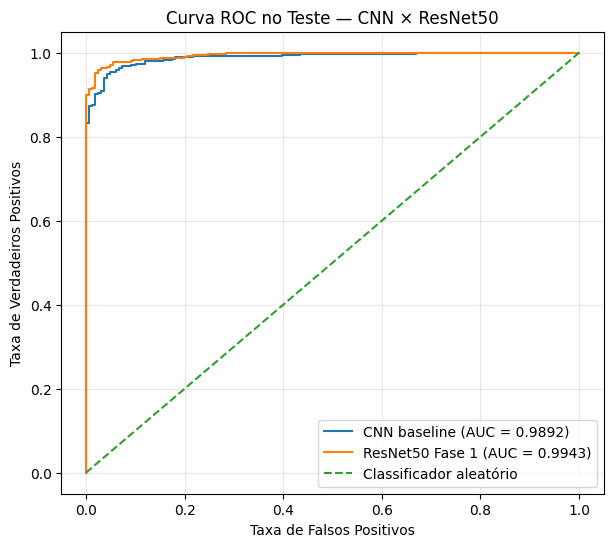

In [52]:
from sklearn.metrics import roc_curve

# CNN oficial
fpr_cnn, tpr_cnn, _ = roc_curve(
    y_true_cnn_oficial,
    y_prob_cnn_oficial
)

# ResNet50
fpr_resnet, tpr_resnet, _ = roc_curve(
    y_true_resnet,
    probabilidades_resnet
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_cnn,
    tpr_cnn,
    label=f"CNN baseline (AUC = {roc_auc_cnn_oficial:.4f})"
)

plt.plot(
    fpr_resnet,
    tpr_resnet,
    label=f"ResNet50 Fase 1 (AUC = {roc_auc_resnet:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificador aleatório"
)

plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC no Teste — CNN × ResNet50")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# ResNet50 com Transfer Learning

## Objetivo

Construir, treinar e avaliar uma ResNet50 com Transfer Learning para a classificação binária `NORMAL` versus `PNEUMONIA`, mantendo exatamente a mesma divisão experimental oficial utilizada na CNN baseline e permitindo comparação direta entre treinamento do zero e reutilização de representações pré-treinadas.

## Dados e protocolo experimental

* Base experimental oficial: `base_modelagem_divisao_80_10_10.csv`.
* Treino: 4.682 imagens — 1.259 `NORMAL` e 3.423 `PNEUMONIA`.
* Validação: 561 imagens — 154 `NORMAL` e 407 `PNEUMONIA`.
* Teste: 581 imagens — 166 `NORMAL` e 415 `PNEUMONIA`.
* Mapeamento: `NORMAL = 0` e `PNEUMONIA = 1`.
* `PNEUMONIA` foi mantida como classe positiva.
* Nenhum novo split foi criado.
* Entrada: `224 × 224 × 3`.
* `BATCH_SIZE = 32`.
* `SEED = 42`.
* Shuffle somente no treino, com `reshuffle_each_iteration=True`.
* `prefetch(tf.data.AUTOTUNE)` nos três conjuntos.
* Sem `cache`, Data Augmentation ou `class_weight` nesta primeira fase.

## Pré-processamento específico da ResNet50

Diferentemente da CNN baseline, não foi aplicada normalização simples para `0–1`. As imagens foram lidas como JPEG com três canais, redimensionadas para `224 × 224`, convertidas para `float32` e processadas com `tf.keras.applications.resnet50.preprocess_input`, preservando compatibilidade com os pesos pré-treinados no ImageNet.

Um batch real foi validado com formato `(32, 224, 224, 3)` para imagens e `(32,)` para rótulos, ambos em `float32`.

## Transfer Learning e arquitetura

Foi utilizada `ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))`.

A base convolucional foi integralmente congelada na Fase 1. A saída da ResNet50 possui formato `(7, 7, 2048)` e foi conectada ao classificador:

1. ResNet50 pré-treinada no ImageNet, congelada;
2. `GlobalAveragePooling2D`;
3. `Dropout(0.5)`;
4. `Dense(1, activation="sigmoid")`.

Parâmetros:

* Totais: 23.589.761.
* Treináveis: 2.049.
* Não treináveis: 23.587.712.

A base foi chamada com `training=False`, mantendo as camadas de Batch Normalization em modo de inferência durante esta fase.

## Compilação e treinamento

* Loss: `BinaryCrossentropy`.
* Otimizador: Adam.
* Learning rate: `0.001`.
* Métricas: Accuracy, Precision, Recall e ROC-AUC.
* Máximo: 30 épocas.
* `EarlyStopping`: `monitor="val_loss"`, `patience=5`, `mode="min"`, `restore_best_weights=True`.
* `ModelCheckpoint`: menor `val_loss`, salvando o melhor modelo completo em `resnet50_transfer_learning_fase1_best.keras`.
* Sem `ReduceLROnPlateau`.

Na execução interativa atual, o treinamento foi encerrado por EarlyStopping na época 25 e restaurou os pesos da melhor época, a época 20.

### Melhor época — execução interativa atual

Treino:

* Loss: 0,093671.
* Accuracy: 0,964332.
* Precision: 0,973807.
* Recall: 0,977505.
* ROC-AUC: 0,992105.

Validação:

* Loss: 0,106106.
* Accuracy: 0,966132.
* Precision: 0,975490.
* Recall: 0,977887.
* ROC-AUC: 0,991033.

As curvas mostraram convergência rápida e posterior estabilização, com pequena diferença entre treino e validação na melhor época. A `val_loss` passou a oscilar nas épocas finais, mas sem afastamento pronunciado entre as curvas comparável ao observado na CNN baseline.

## Avaliação no teste — execução interativa atual

O melhor checkpoint foi recarregado antes da avaliação.

Resultados em 581 imagens:

* Loss: 0,088589.
* Accuracy: 0,967298 — 96,73%.
* Precision: 0,978261 — 97,83%.
* Recall: 0,975904 — 97,59%.
* F1-score: 0,977081 — 97,71%.
* ROC-AUC scikit-learn: 0,994324 — 99,43%.
* ROC-AUC Keras: aproximadamente 0,994361.

Matriz de confusão com threshold `0,5`:

`[[157, 9], [10, 405]]`

* TN = 157.
* FP = 9.
* FN = 10.
* TP = 405.
* Acertos: 562.
* Erros: 19.

## Análise de erros

Falsos positivos — 9 casos:

* Média do score de PNEUMONIA: 0,8157.
* Mediana: 0,7881.
* Mínimo: 0,6714.
* Máximo: 0,9598.

Falsos negativos — 10 casos:

* Média do score de PNEUMONIA: 0,2320.
* Mediana: 0,1800.
* Mínimo: 0,0806.
* Máximo: 0,4754.

Erros extremos:

### NORMAL → PNEUMONIA

* `NORMAL2-IM-0330-0001.jpeg` → 0,959826.
* `NORMAL2-IM-0316-0001.jpeg` → 0,952511.
* `NORMAL2-IM-0222-0001.jpeg` → 0,918017.

### PNEUMONIA → NORMAL

* `person277_virus_571.jpeg` → 0,080580.
* `person435_virus_885.jpeg` → 0,086508.
* `person703_virus_1300.jpeg` → 0,112276.

A inspeção visual não revelou um único artefato capaz de explicar consistentemente os seis erros de alta confiança. Marcadores, diferenças de enquadramento, contraste e áreas externas aparecem em diferentes tipos de erro. `person277_virus_571.jpeg` e `person703_virus_1300.jpeg` também aparecem entre erros relevantes da CNN, caracterizando casos particularmente difíceis para arquiteturas distintas.

## Associação descritiva com características técnicas

As medianas foram analisadas controlando pela classe verdadeira.

### NORMAL

Acertos:

* largura: 1.724;
* altura: 1.392;
* razão de aspecto: 1,217;
* pixels totais: 2.372.692.

Erros `NORMAL → PNEUMONIA`:

* largura: 1.504;
* altura: 1.136;
* razão de aspecto: 1,424;
* pixels totais: 1.644.928.

### PNEUMONIA

Acertos:

* largura: 1.152;
* altura: 776;
* razão de aspecto: 1,506;
* pixels totais: 896.040.

Erros `PNEUMONIA → NORMAL`:

* largura: 1.648;
* altura: 1.364,5;
* razão de aspecto: 1,274;
* pixels totais: 2.256.900.

O sentido do deslocamento é consistente com os perfis técnicos identificados na EDA e com o padrão previamente observado na CNN: PNEUMONIAS classificadas como NORMAL apresentam maior resolução e menor razão de aspecto, enquanto NORMAL classificadas como PNEUMONIA apresentam menor resolução e maior razão de aspecto. Há sobreposição entre as distribuições e os grupos de erro são pequenos; portanto, a associação é descritiva e não estabelece causalidade.

## Comparação oficial com a CNN baseline versionada

A CNN de referência utilizada na comparação é exclusivamente a `Version #1 — Successful` do Notebook 03, preservada pelo Kaggle.

| Métrica      | CNN baseline — Version #1 | ResNet50 Fase 1 — execução interativa atual |
| ------------ | ------------------------: | ------------------------------------------: |
| Loss         |                  0,127318 |                                    0,088589 |
| Accuracy     |                    94,66% |                                      96,73% |
| Precision    |                    95,28% |                                      97,83% |
| Recall       |                    97,35% |                                      97,59% |
| F1-score     |                    96,31% |                                      97,71% |
| ROC-AUC      |                    98,92% |                                      99,43% |
| FP           |                        20 |                                           9 |
| FN           |                        11 |                                          10 |
| Erros totais |                        31 |                                          19 |

Ganhos da ResNet50 na execução interativa atual:

* Accuracy: +2,065 p.p.
* Precision: +2,543 p.p.
* Recall: +0,241 p.p.
* F1-score: +1,403 p.p.
* ROC-AUC: +0,514 p.p.
* Redução relativa de erros totais: 38,71%.
* Redução de falsos positivos: 55,00%.
* Redução de falsos negativos: 9,09%.

O principal ganho ocorreu na redução dos falsos positivos, elevando a Precision, enquanto o Recall já era alto na CNN e apresentou melhora discreta.

## Comparação imagem a imagem

Das 581 imagens do teste:

* 541 foram corretamente classificadas pelos dois modelos;
* 10 foram erradas pelos dois;
* 21 eram erros da CNN corrigidos pela ResNet50;
* 9 eram acertos da CNN que se tornaram erros na ResNet50.

Entre os 10 erros compartilhados, 5 são FP e 5 são FN.

Dos 21 erros da CNN corrigidos pela ResNet50:

* 15 eram FP;
* 6 eram FN.

Dos 9 novos erros introduzidos pela ResNet50:

* 4 são novos FP;
* 5 são novos FN.

A concordância no erro não implica que as arquiteturas utilizem as mesmas regiões ou representações. Os casos compartilhados serão candidatos prioritários para análise comparativa com Grad-CAM.

## Decisão sobre fine-tuning

O fine-tuning não foi incorporado ao escopo principal. A Fase 1 com base congelada já apresentou forte desempenho e pequena diferença entre treino e validação. Além disso, como o conjunto de teste já havia sido utilizado para avaliação, não seria metodologicamente adequado utilizar seu resultado para decidir alterações destinadas a aumentar desempenho.

O fine-tuning permanece como possível extensão futura e não é possível afirmar, sem experimento específico, se produziria ganhos adicionais.

## Reprodutibilidade e fechamento formal

Após a auditoria da CNN, foi acrescentado no início do Notebook 04, antes da construção do modelo:

```python
SEED = 42

tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
```

Essa configuração busca reduzir a estocasticidade entre execuções, embora não garanta reprodução absoluta entre diferentes versões de software, hardware e ambientes.

**Importante:** os resultados numéricos da ResNet50 documentados acima correspondem à execução interativa atual, realizada antes do `Save Version / Run All` com o determinismo explicitamente habilitado. O fechamento formal da Etapa 9 exige uma execução integral versionada no Kaggle. Se os números da versão `Successful` diferirem, a versão preservada deverá substituir os valores interativos na documentação final.

## Artefatos gerados na execução atual

* `resnet50_transfer_learning_fase1_best.keras`.
* `historico_treinamento_resnet50_fase1.csv` — 25 × 11.
* `analise_teste_resnet50_fase1.csv` — 581 × 22.
* `resumo_resultados_resnet50_fase1.csv` — 34 × 2.
* `comparacao_cnn_resnet50.csv` — 11 × 3.
* `ganhos_resnet50_sobre_cnn.csv` — 5 × 5.
* `comparacao_imagem_a_imagem_cnn_resnet50.csv` — 581 × 12.

## Conclusão técnica da Etapa 9

A ResNet50 com Transfer Learning e base convolucional congelada apresentou, na execução interativa atual, desempenho superior à CNN baseline versionada em todas as métricas agregadas do teste, com destaque para a redução de falsos positivos. O modelo alcançou esse resultado treinando apenas 2.049 parâmetros do classificador final, enquanto 23.587.712 parâmetros pré-treinados permaneceram congelados. A recorrência de erros associados a perfis técnicos das imagens em duas arquiteturas distintas reforça a necessidade de análise posterior com Grad-CAM para investigar possíveis atalhos e regiões utilizadas pelos modelos.

**Status: ETAPA 9 TECNICAMENTE CONCLUÍDA NA EXECUÇÃO INTERATIVA; FECHAMENTO FORMAL PENDENTE DO SAVE VERSION / RUN ALL E DA AUDITORIA DA VERSÃO SUCCESSFUL.**
